# FOV Finder Agent — "extremes" selection mode

Same scanning pipeline as [simple_fov_finder_demo.ipynb](./simple_fov_finder_demo.ipynb),
but instead of **farthest-point sampling** (maximally spread in space),
the finder picks FOVs that span the **extremes of a feature axis** — by
default `n_cells`.

Motivation: when you want a contrast pair (sparsest vs densest FOV
inside the valid cell-count window), FPS doesn't help — it gives you
spatial spread, not feature spread.

Example with `min_cells=35`, `max_cells=200`, `fovs_per_well=2` and
four valid candidates with cell counts `[36, 135, 136, 200]`:

- `selection_mode="farthest_point"` → picks the two candidates
    whose (x, y) are furthest apart (feature-agnostic).
- `selection_mode="extremes"` → picks the **36** and **200** candidates.

For `fovs_per_well=k`, `extremes` returns `k` evenly-spaced positions
along the sorted feature axis:

| `k` | pick                          |
|----:|-------------------------------|
| 1   | median candidate              |
| 2   | min, max                      |
| 3   | min, median, max              |
| 4   | min, ~33 %, ~66 %, max        |

**Tiebreak:** when several candidates share similar feature values
(e.g. two candidates both at the max), the finder breaks ties by
**spatial distance** — candidates farthest from already-picked FOVs
win, so equally-extreme picks don't end up clustered in the well.

`selection_feature` switches the axis — any column in the scan
DataFrame works (`"n_cells"`, `"fe_cnr_mean"`, …).

## 1. Microscope and channel setup

In [1]:
from faro.microscope.pertzlab.jungfrau import Jungfrau
from faro.core.data_structures import PowerChannel

mic = Jungfrau()
mic.mmc.setChannelGroup("TTL_ERK")

# The finder only acquires imaging channels; stim/ref are intentionally
# not part of the scan.
imaging_channels = (
    PowerChannel(config="miRFP", exposure=125, group="TTL_ERK", power=95),
)

In [2]:
mic.mmc.setProperty("TIPFSStatus", "State", "On")  # PFS holds focus

## 2. Plate calibration

In [3]:
PLATE_CALIBRATION_PATH = "./calib_plate_96.json"

from useq import WellPlatePlan

plan = WellPlatePlan.from_file(PLATE_CALIBRATION_PATH)
print(f"plate: {plan.plate.name}  rows={plan.plate.rows}  cols={plan.plate.columns}")

plate: 96-well  rows=8  cols=12


## 3. Segmentator

In [4]:
from faro.segmentation.cellpose_v4 import CellposeV4

segmentator = CellposeV4()

## 4. FOV finder in `extremes` mode

Key additions compared to the simple demo:

- `selection_mode="extremes"` — replaces the default farthest-point
    sampler.
- `selection_feature="n_cells"` — axis to walk (default; change to e.g.
    `"fe_cnr_mean"` when a `feature_extractor` is wired up).

With `fovs_per_well=2`, each well yields **its lowest and highest
cell-count candidate within `[min_cells, max_cells]`** — a natural
sparse/dense contrast pair per well.

In [5]:
from faro.agents import FOVFinderAgent

wells = ["B2", "B3", "B4"]

finder = FOVFinderAgent(
    microscope=mic,
    well_plate_plan=PLATE_CALIBRATION_PATH,
    wells=wells,
    fovs_per_well=2,  # want a sparse/dense pair per well
    n_candidates_per_well=8,  # scan enough so the pair is meaningful
    border_um=1500.0,
    min_distance_um=1000.0,
    min_cells=35,  # valid window: [35, 200] cells
    max_cells=200,
    imaging_channels=imaging_channels,
    segmentator=segmentator,
    seg_channel_index=0,
    # --- new knobs ---
    selection_mode="extremes",  # pick extremes of the feature axis
    selection_feature="n_cells",  # axis = cell count
    # -----------------
    z=None,
    random_seed=42,
    verbose=True,
)

[FOVFinderAgent] Phase 0: scanning 8 candidates in 3 wells: ['B2', 'B3', 'B4']


C:\Users\Jungfrau\Documents\alandolt\code\faro\faro\agents\fov_finder.py:583: UserWarning: Unable to generate 8 non-overlapping points. Only 7 points were found.
  return np.array([(p.x, p.y) for p in rp], dtype=float)


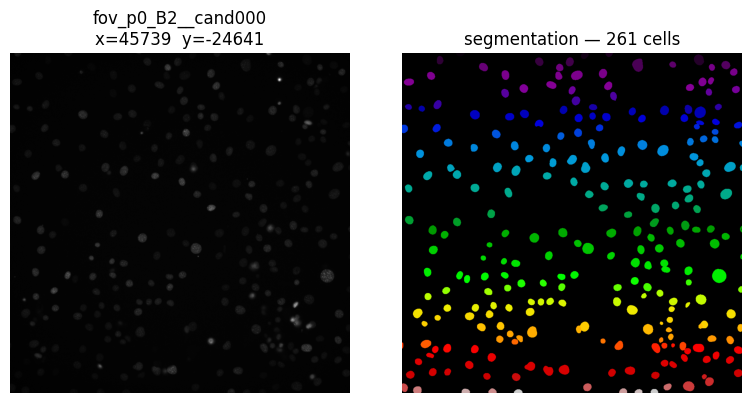

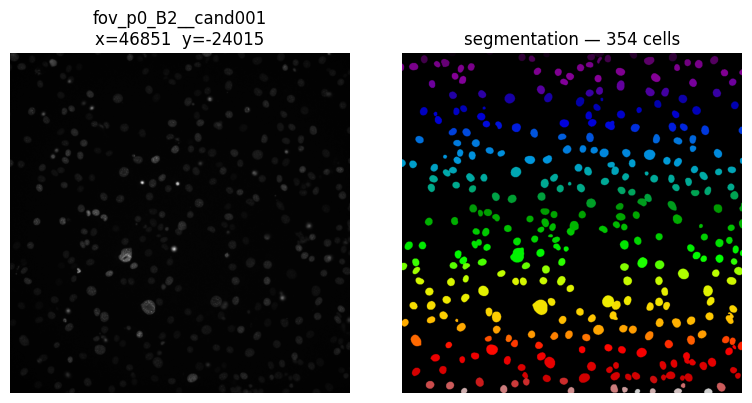

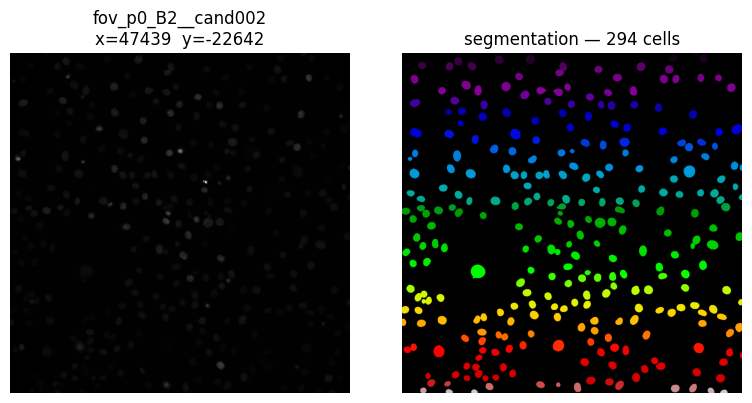

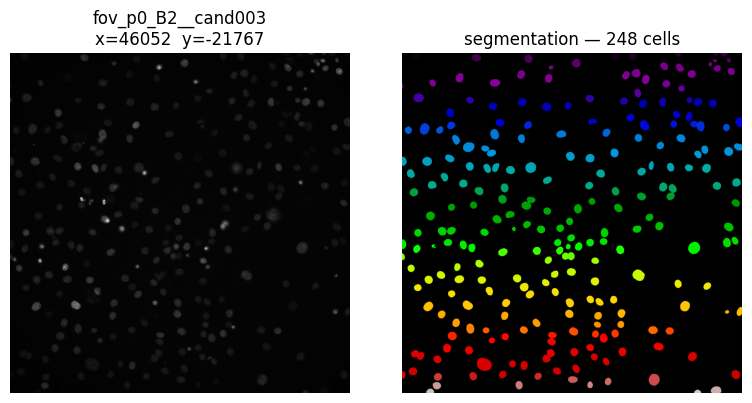

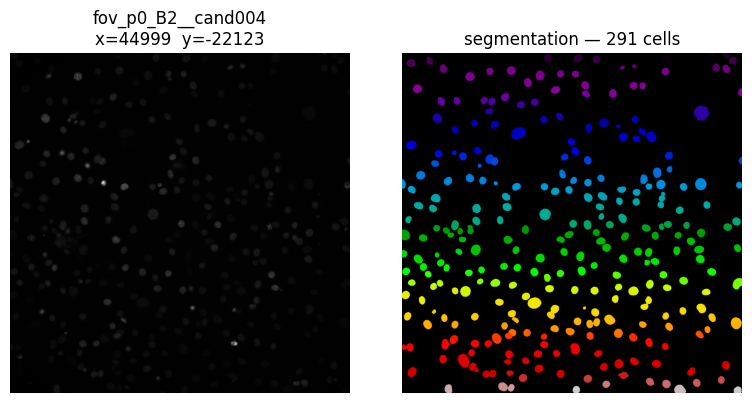

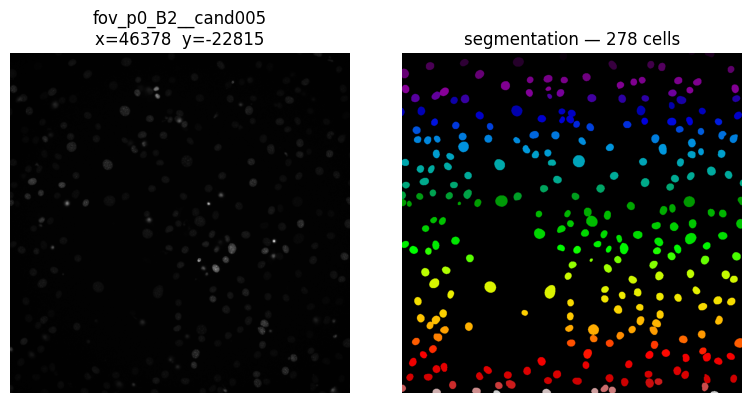

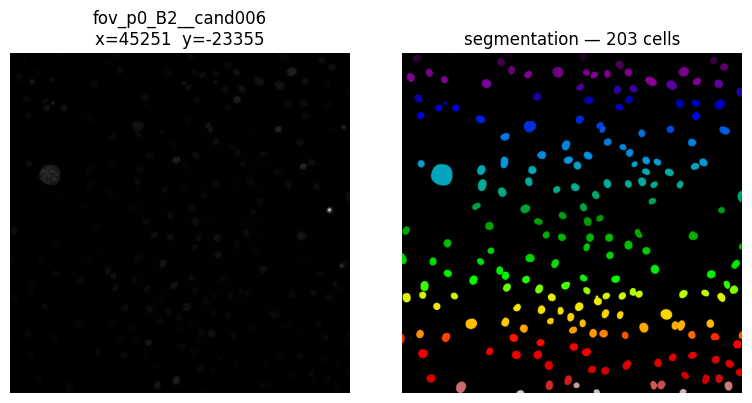

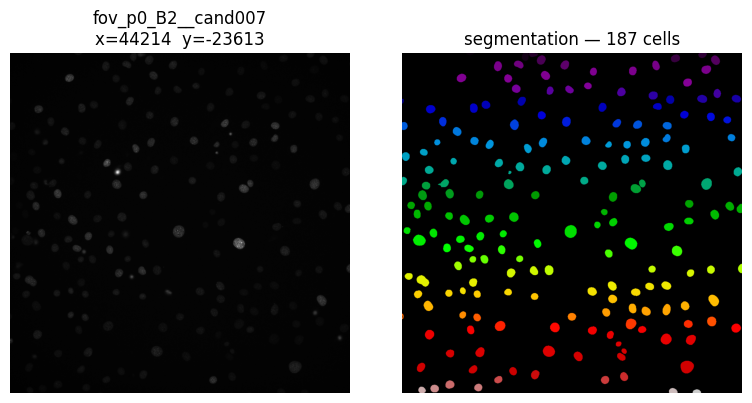

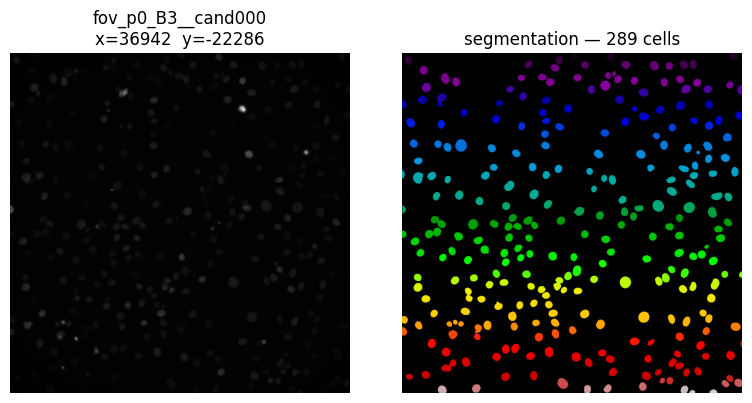

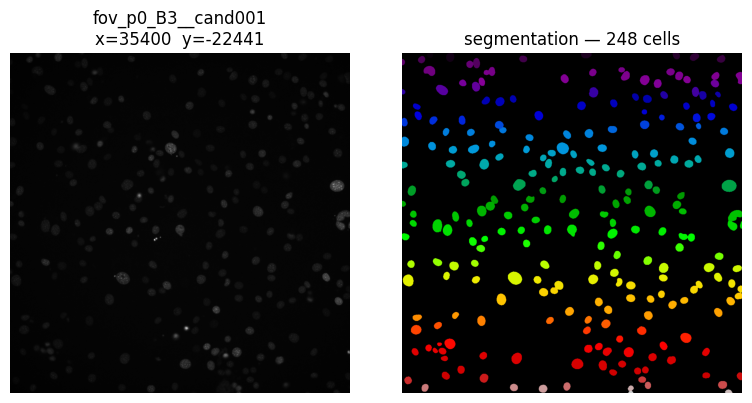

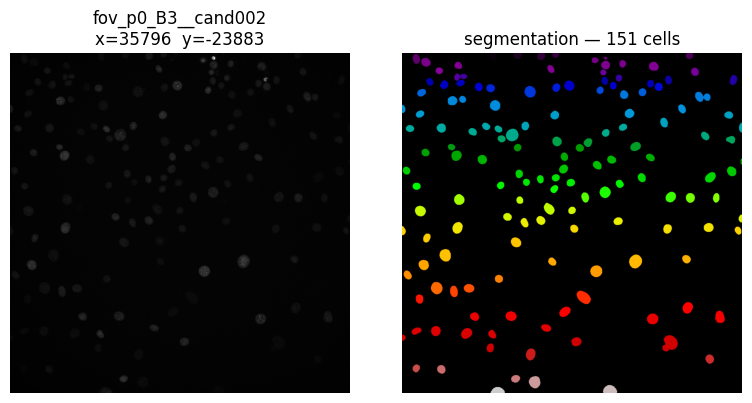

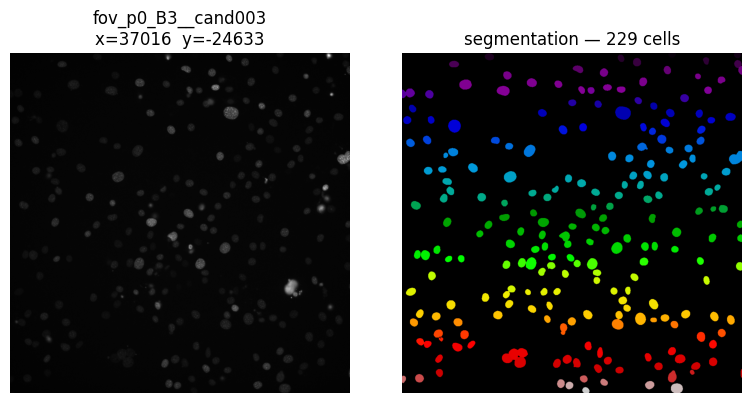

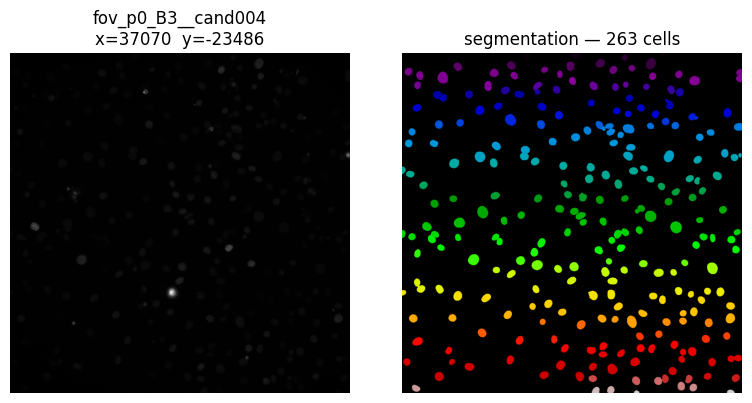

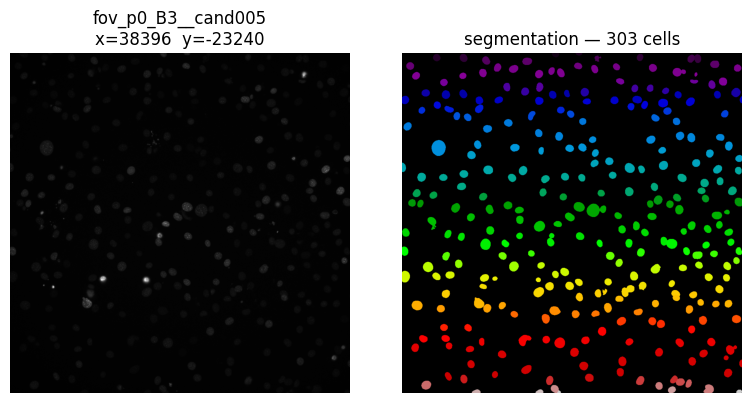

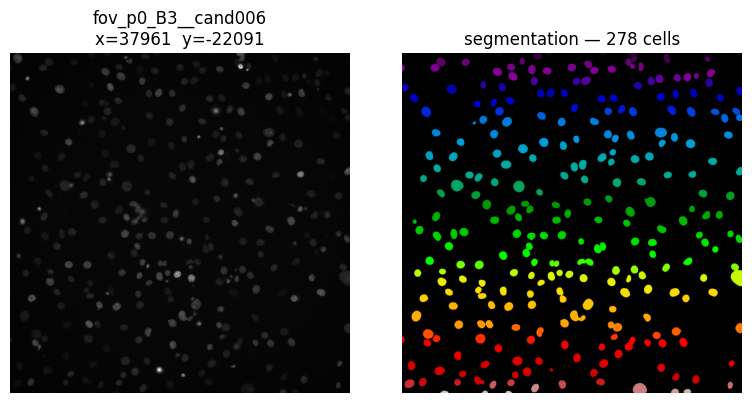

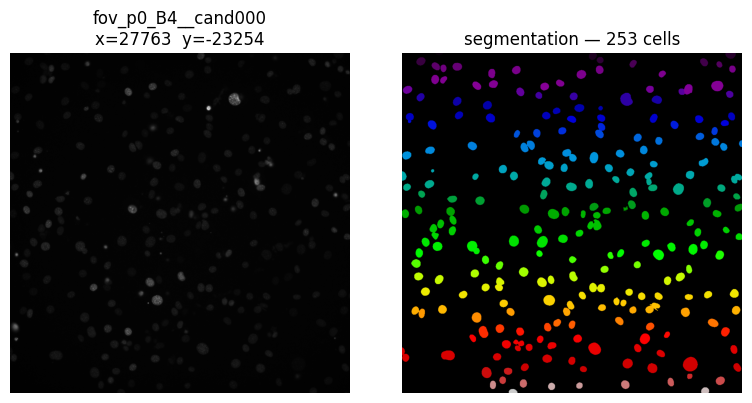

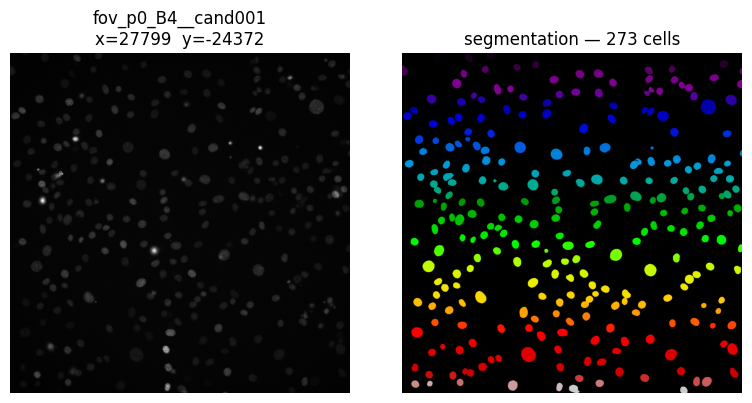

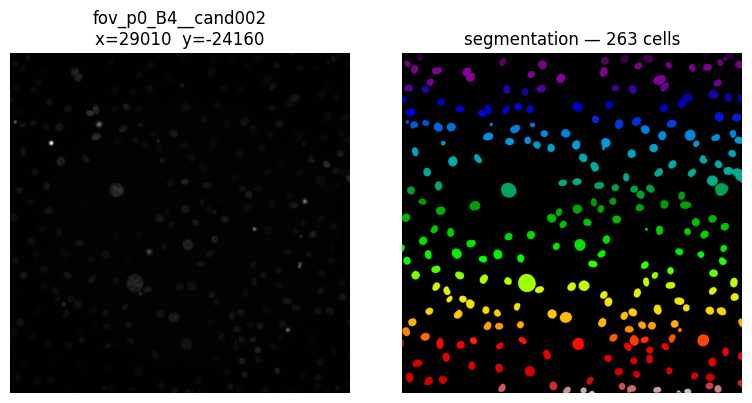

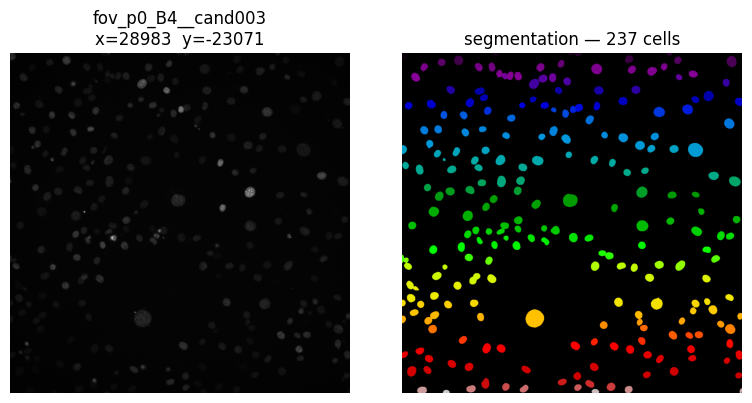

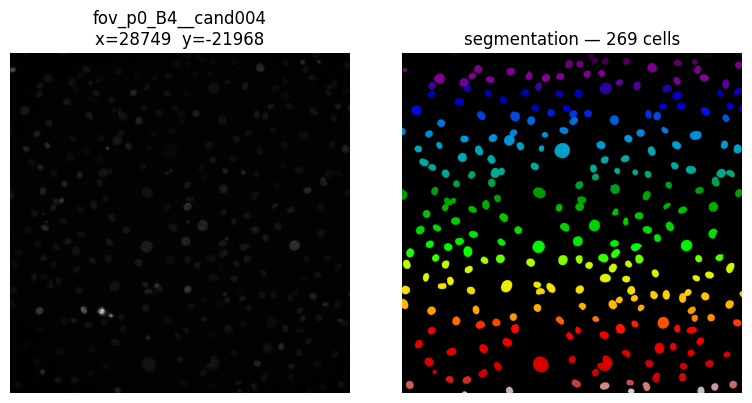

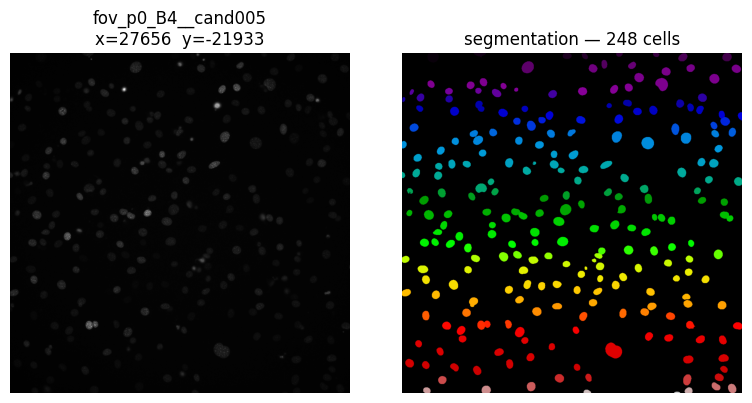

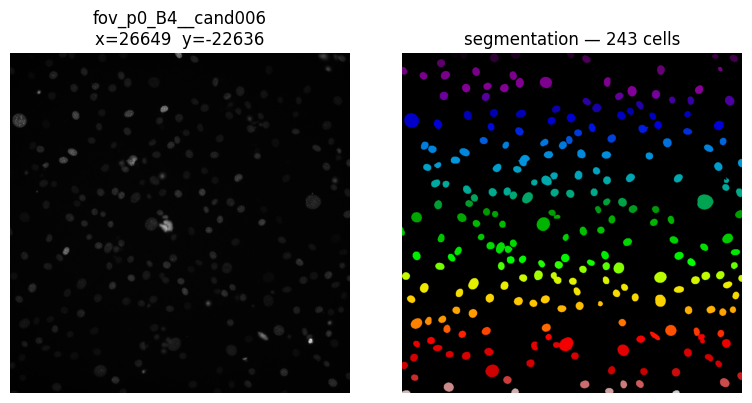

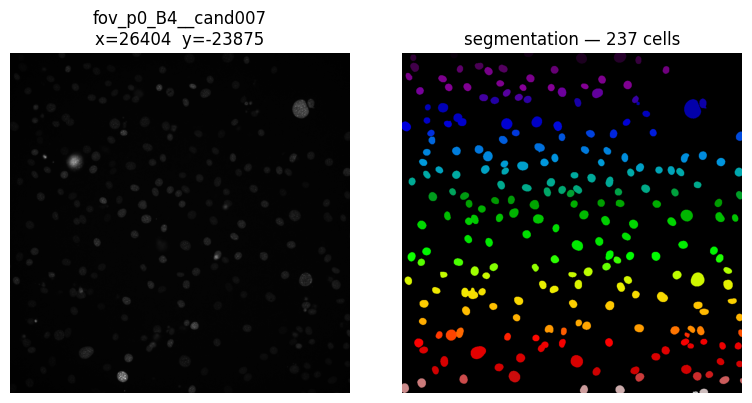

[FOVFinderAgent] WARNING: well B2 only had 1/2 valid positions; padded with 1 below-threshold candidates (best n_cells=354).
[FOVFinderAgent] WARNING: well B3 only had 1/2 valid positions; padded with 1 below-threshold candidates (best n_cells=303).
[FOVFinderAgent] WARNING: well B4 only had 0/2 valid positions; padded with 2 below-threshold candidates (best n_cells=273).


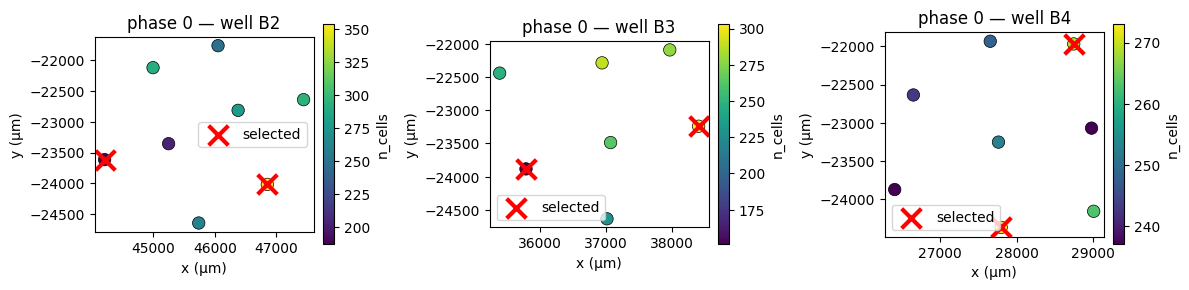

[FOVFinderAgent] Phase 0: selected 6 FOVs across 3 wells (median valid candidates/well: 1).


[FovPosition(x=44213.68604200181, y=-23613.419479343545, z=None, name='B2_0000'),
 FovPosition(x=46851.49524161627, y=-24015.45162079073, z=None, name='B2_0001'),
 FovPosition(x=35796.392298064726, y=-23882.60169605323, z=None, name='B3_0000'),
 FovPosition(x=38395.61347592689, y=-23240.40103346491, z=None, name='B3_0001'),
 FovPosition(x=27799.063443011226, y=-24371.602445795215, z=None, name='B4_0000'),
 FovPosition(x=28749.268206255554, y=-21967.69669159594, z=None, name='B4_0001')]

In [6]:
selected = finder.run()
selected

### Verify the picks are the extremes

For each well, list every scanned candidate's cell count and mark the
ones the finder selected. The selected pair should be the **lowest and
highest valid cell counts** inside `[min_cells, max_cells]`.

In [7]:
df_scan = finder.last_run["all_candidates"]
selected_xy = {(round(fp.x, 3), round(fp.y, 3)) for fp in selected}

df_scan = df_scan.assign(
    picked=[
        (round(x, 3), round(y, 3)) in selected_xy
        for x, y in zip(df_scan["x"], df_scan["y"])
    ]
)
df_scan[["well", "n_cells", "valid", "reason", "picked"]].sort_values(
    ["well", "n_cells"]
)

,well,n_cells,valid,reason,picked
7,B2,187,True,,True
6,B2,203,False,above_max_cells,False
3,B2,248,False,above_max_cells,False
0,B2,261,False,above_max_cells,False
5,B2,278,False,above_max_cells,False
4,B2,291,False,above_max_cells,False
2,B2,294,False,above_max_cells,False
1,B2,354,False,above_max_cells,True
10,B3,151,True,,True
11,B3,229,False,above_max_cells,False


## 5. Three-way contrast: `fovs_per_well=3`

With three picks, `extremes` returns **min, median, max** — useful when
you want a low / medium / high density trio per well in a single
acquisition batch.

[FOVFinderAgent] Phase 0: scanning 8 candidates in 2 wells: ['C2', 'C3']


C:\Users\Jungfrau\Documents\alandolt\code\faro\faro\agents\fov_finder.py:583: UserWarning: Unable to generate 8 non-overlapping points. Only 7 points were found.
  return np.array([(p.x, p.y) for p in rp], dtype=float)
C:\Users\Jungfrau\Documents\alandolt\code\faro\faro\agents\fov_finder.py:583: UserWarning: Unable to generate 8 non-overlapping points. Only 6 points were found.
  return np.array([(p.x, p.y) for p in rp], dtype=float)


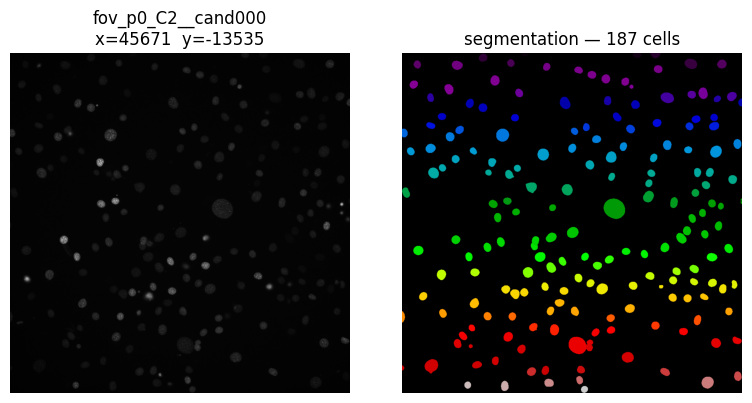

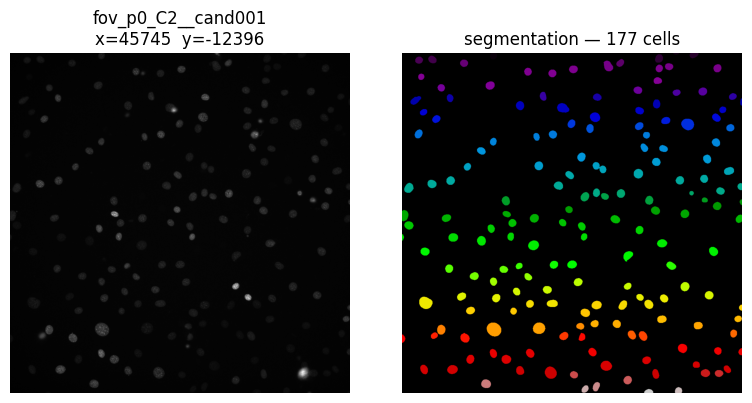

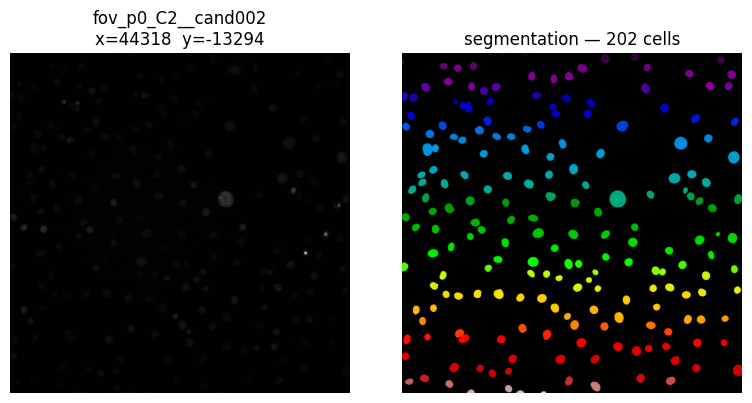

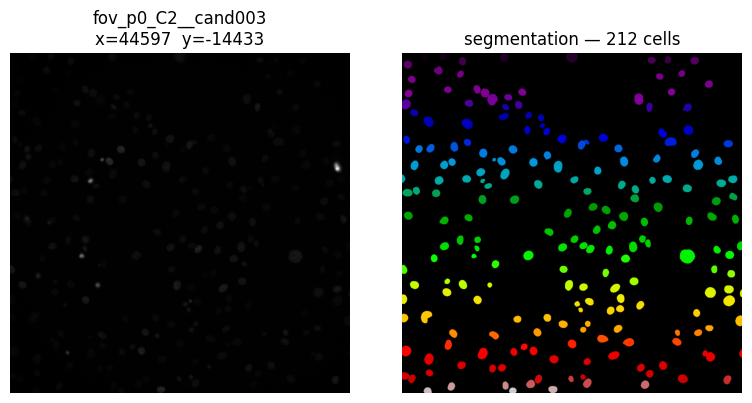

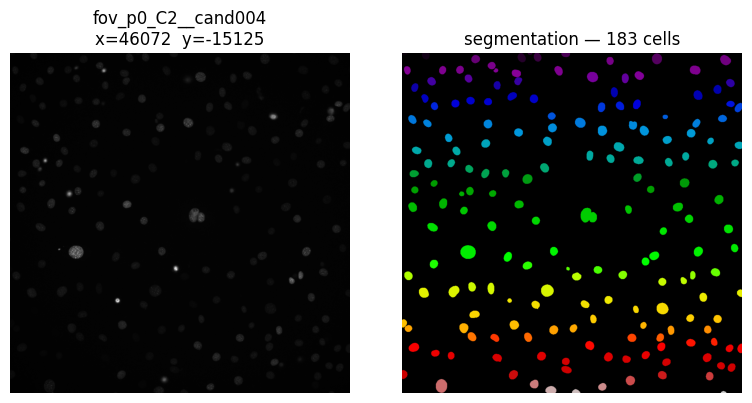

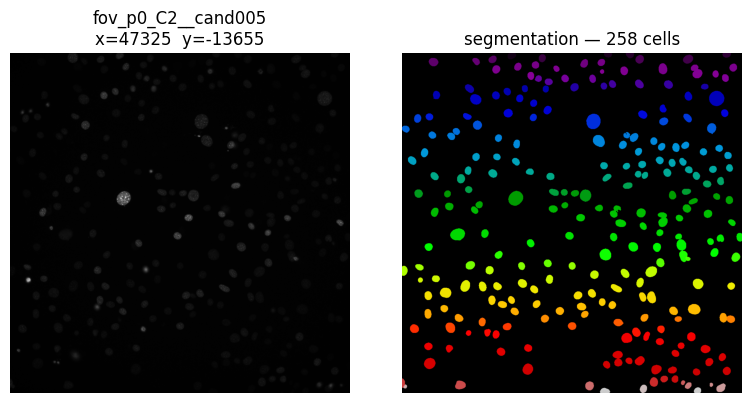

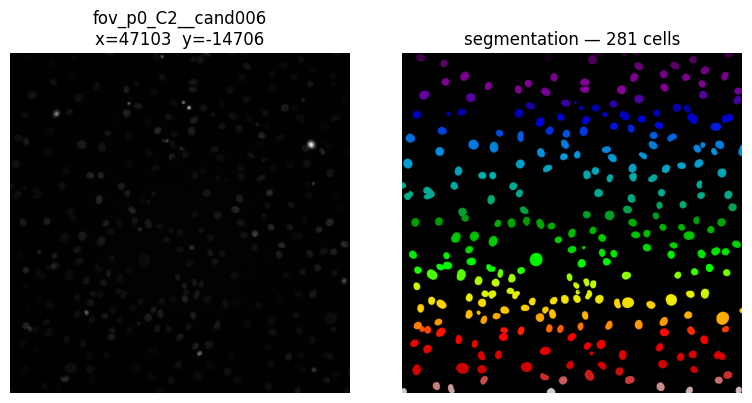

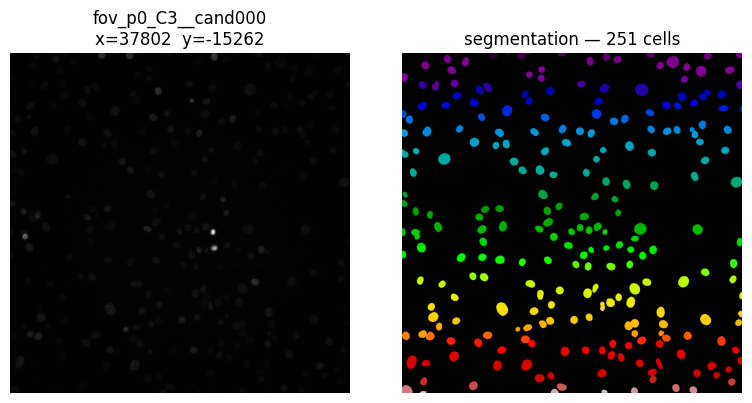

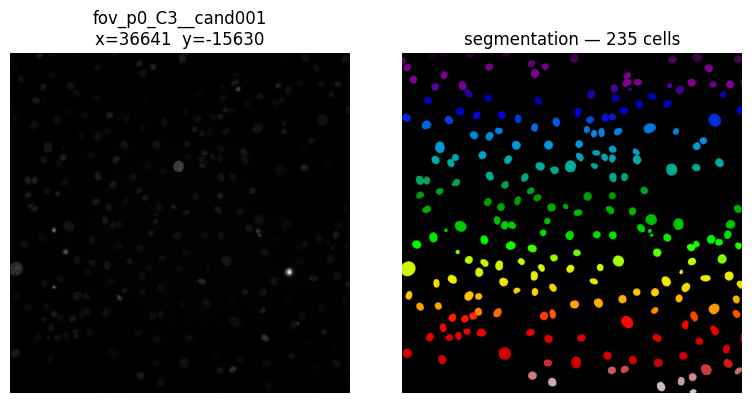

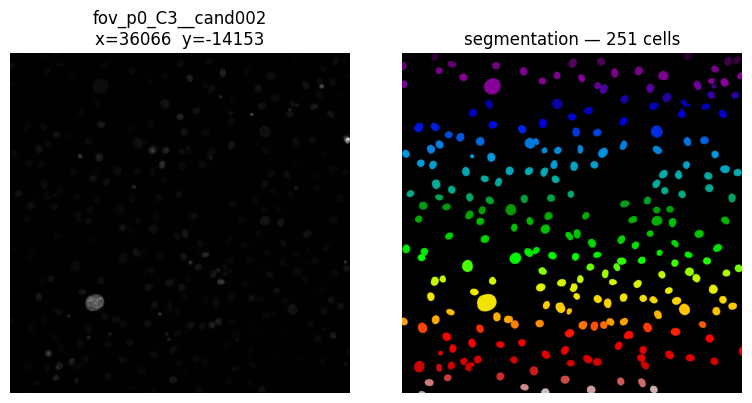

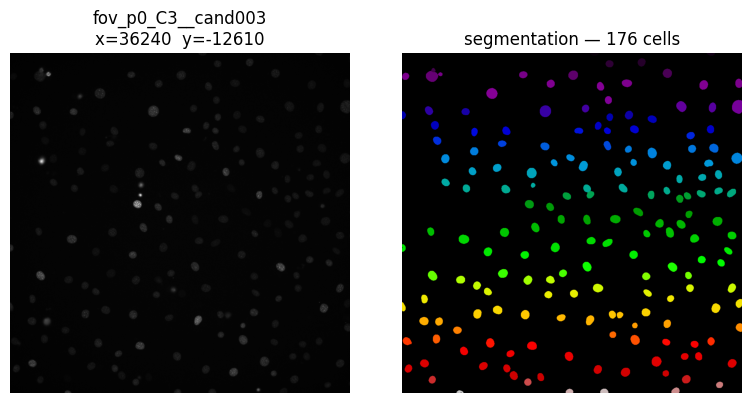

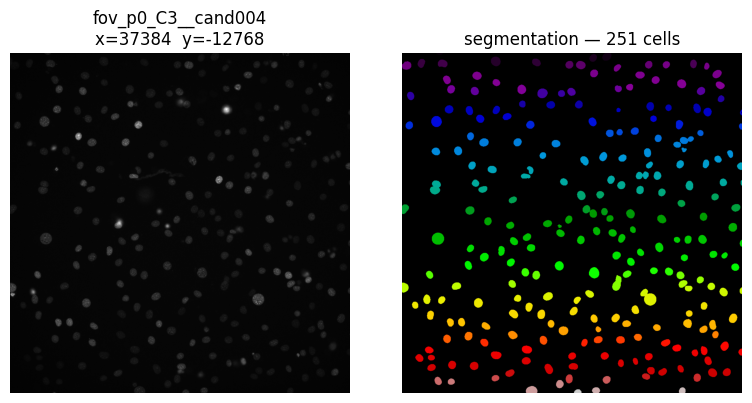

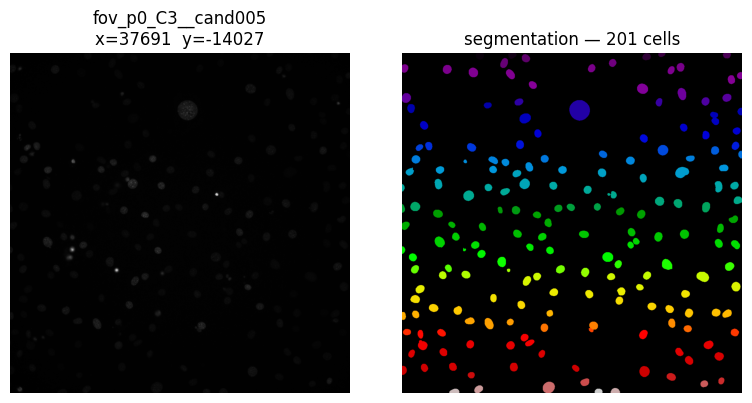

[FOVFinderAgent] WARNING: well C3 only had 1/3 valid positions; padded with 2 below-threshold candidates (best n_cells=251).


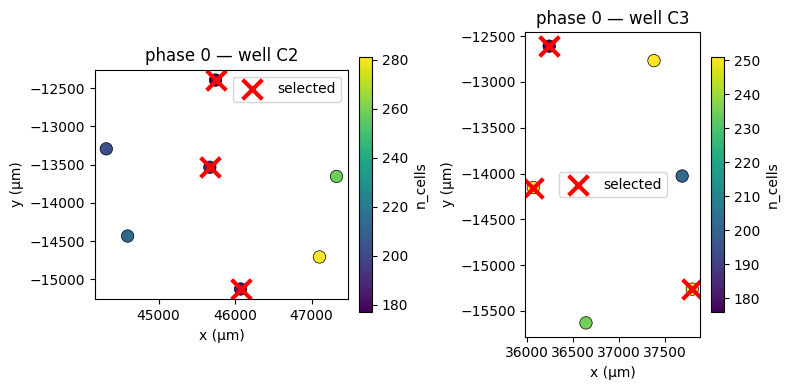

[FOVFinderAgent] Phase 0: selected 6 FOVs across 2 wells (median valid candidates/well: 2).


[FovPosition(x=45744.885506237166, y=-12396.186409788537, z=None, name='C2_0000'),
 FovPosition(x=46072.25978260292, y=-15124.694318534022, z=None, name='C2_0001'),
 FovPosition(x=45670.61291509304, y=-13534.823711782548, z=None, name='C2_0002'),
 FovPosition(x=36239.94116312448, y=-12610.227795233423, z=None, name='C3_0000'),
 FovPosition(x=37801.7123990686, y=-15261.572882879593, z=None, name='C3_0001'),
 FovPosition(x=36066.38442895773, y=-14152.742500309374, z=None, name='C3_0002')]

In [8]:
finder3 = FOVFinderAgent(
    microscope=mic,
    well_plate_plan=PLATE_CALIBRATION_PATH,
    wells=["C2", "C3"],
    fovs_per_well=3,
    n_candidates_per_well=8,
    border_um=1500.0,
    min_distance_um=1000.0,
    min_cells=35,
    max_cells=200,
    imaging_channels=imaging_channels,
    segmentator=segmentator,
    seg_channel_index=0,
    selection_mode="extremes",
    selection_feature="n_cells",
    z=None,
    random_seed=7,
    verbose=True,
)

picks3 = finder3.run()
picks3

## 6. Tip — choose a different feature axis

`selection_feature` accepts any column produced by the scan. Pair it
with a `feature_extractor` to pick extremes of e.g. biosensor contrast
instead of cell count:

```python
from faro.feature_extraction.erk_ktr import FE_ErkKtr

FOVFinderAgent(
    ...,
    feature_extractor=FE_ErkKtr(...),  # adds fe_cnr_mean column
    selection_mode="extremes",
    selection_feature="fe_cnr_mean",   # pick lowest- vs highest-CNR FOV
)
```

This does not *filter* FOVs on the feature — it only shapes which valid
candidates get picked. For hard thresholds ("reject any FOV where
fewer than 80 % of cells have CNR < 0.6"), use `fov_conditions` —
see [cnr_fov_finder_demo.ipynb](./cnr_fov_finder_demo.ipynb).